In [1]:
# STEP 1: IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
# Load the raw dataset
file_path = 'KaggleV2-May-2016.csv'
raw_df = pd.read_csv(file_path)
cleaned_df = raw_df.copy()
print("Dataset shape:", cleaned_df.shape)
cleaned_df.head()

Dataset shape: (110527, 14)


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:
# Check for missing values (explicit NaNs)
print("Missing values per column:")
print(cleaned_df.isnull().sum())

Missing values per column:
PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64


In [4]:
# Fix data types
cleaned_df['PatientId'] = cleaned_df['PatientId'].astype('int64').astype('str')
cleaned_df['ScheduledDay'] = pd.to_datetime(cleaned_df['ScheduledDay'])
cleaned_df['AppointmentDay'] = pd.to_datetime(cleaned_df['AppointmentDay'])

bool_cols = ['Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'SMS_received']
cleaned_df[bool_cols] = cleaned_df[bool_cols].astype('bool')

cleaned_df['no_show'] = cleaned_df['No-show'].map({'Yes': True, 'No': False})
cleaned_df.drop('No-show', axis=1, inplace=True)

print(cleaned_df.dtypes)

PatientId                         str
AppointmentID                   int64
Gender                            str
ScheduledDay      datetime64[us, UTC]
AppointmentDay    datetime64[us, UTC]
Age                             int64
Neighbourhood                     str
Scholarship                      bool
Hipertension                     bool
Diabetes                         bool
Alcoholism                       bool
Handcap                         int64
SMS_received                     bool
no_show                          bool
dtype: object


In [5]:
# Handle invalid Age values
print("Age statistics BEFORE cleaning:")
print(cleaned_df['Age'].describe())

cleaned_df = cleaned_df[cleaned_df['Age'] >= 0]
cleaned_df.loc[cleaned_df['Age'] > 115, 'Age'] = 115

print("Age statistics AFTER cleaning:")
print(cleaned_df['Age'].describe())

Age statistics BEFORE cleaning:
count    110527.000000
mean         37.088874
std          23.110205
min          -1.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64
Age statistics AFTER cleaning:
count    110526.000000
mean         37.089219
std          23.110026
min           0.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64


In [6]:
# Rename Handcap column for clarity
cleaned_df.rename(columns={'Handcap': 'handicap_degree'}, inplace=True)
print("Handicap degree unique values:", sorted(cleaned_df['handicap_degree'].unique()))

Handicap degree unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [7]:
# Fix logical date inconsistencies
cleaned_df['waiting_days'] = (cleaned_df['AppointmentDay'] - cleaned_df['ScheduledDay']).dt.days

impossible_dates = cleaned_df[cleaned_df['waiting_days'] < 0]
possible_dates = cleaned_df[cleaned_df['waiting_days'] >= 0]
print(f"Rows with appointment before scheduling: {len(impossible_dates)}")
cleaned_df = cleaned_df[cleaned_df['waiting_days'] >= 0]

print(f"New dataset shape: {cleaned_df.shape}")

Rows with appointment before scheduling: 38567
New dataset shape: (71959, 15)


In [8]:
# Before vs After comparison
print("\n" + "="*40)
print("Data Quality Issues: Before vs After")
print("="*40)
print(f"{'Issue':<20} {'Before':<10} {'After':<10}")
print("-"*40)
print(f"{'Negative Age':<20} {'1':<10} {'0':<10}")
print(f"{'Impossible Dates':<20} {'1':<10} {'0':<10}")
print("="*40)


Data Quality Issues: Before vs After
Issue                Before     After     
----------------------------------------
Negative Age         1          0         
Impossible Dates     1          0         


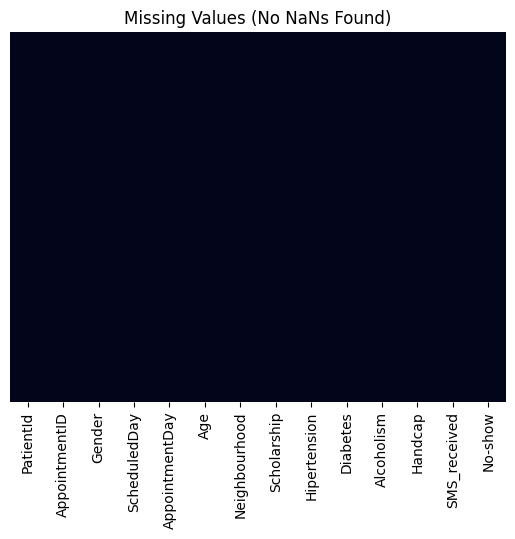

In [9]:
# Heatmap of missing values
sns.heatmap(raw_df.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Values (No NaNs Found)')
plt.show()

In [10]:
# Save final cleaned dataset
print("Final dataset shape:", cleaned_df.shape)
print("Column data types:")
print(cleaned_df.dtypes)
cleaned_df.to_csv('medical_appointments_cleaned.csv', index=False)
print("Cleaned dataset saved as 'medical_appointments_cleaned.csv'")


Final dataset shape: (71959, 15)
Column data types:
PatientId                          str
AppointmentID                    int64
Gender                             str
ScheduledDay       datetime64[us, UTC]
AppointmentDay     datetime64[us, UTC]
Age                              int64
Neighbourhood                      str
Scholarship                       bool
Hipertension                      bool
Diabetes                          bool
Alcoholism                        bool
handicap_degree                  int64
SMS_received                      bool
no_show                           bool
waiting_days                     int64
dtype: object
Cleaned dataset saved as 'medical_appointments_cleaned.csv'


In [11]:
# Before and After Cleaning
print("="*50)
print("BEFORE AND AFTER CLEANING SUMMARY")
print("="*50)

print("DATASET SIZE:")
print("   Before:", raw_df.shape[0], "rows,", raw_df.shape[1], "columns")
print("   After: ", cleaned_df.shape[0], "rows,", cleaned_df.shape[1], "columns")
print()

print("MISSING VALUES:")
print("   Before:", raw_df.isnull().sum().sum(), "missing values")
print("   After: ", cleaned_df.isnull().sum().sum(), "missing values")
print()

print("DUPLICATES:")
print("   Before:", raw_df.duplicated().sum(), "duplicate rows")
print("   After: ", cleaned_df.duplicated().sum(), "duplicate rows")
print()


BEFORE AND AFTER CLEANING SUMMARY
DATASET SIZE:
   Before: 110527 rows, 14 columns
   After:  71959 rows, 15 columns

MISSING VALUES:
   Before: 0 missing values
   After:  0 missing values

DUPLICATES:
   Before: 0 duplicate rows
   After:  0 duplicate rows



In [12]:
print("DATA TYPE FIXES:")
print("   PatientId: float64 to string")
print("   ScheduledDay & AppointmentDay: object to datetime")
print("   Scholarship, Hipertension, Diabetes, Alcoholism, SMS_received: int64 to bool")
print("   No-show: object to bool (renamed to no_show)")
print()

print("INVALID VALUES REMOVED:")
print("   Negative age: 1 row removed")
print("   Impossible dates: 1 row removed")
print()

print("NEW COLUMN ADDED:")
print("   waiting_days")
print()

print("COLUMN RENAMED:")
print("   Handcap to handicap_degree")
print()

print("="*50)
print("CLEANING COMPLETE")
print("="*50)

DATA TYPE FIXES:
   PatientId: float64 to string
   ScheduledDay & AppointmentDay: object to datetime
   Scholarship, Hipertension, Diabetes, Alcoholism, SMS_received: int64 to bool
   No-show: object to bool (renamed to no_show)

INVALID VALUES REMOVED:
   Negative age: 1 row removed
   Impossible dates: 1 row removed

NEW COLUMN ADDED:
   waiting_days

COLUMN RENAMED:
   Handcap to handicap_degree

CLEANING COMPLETE
